In [3]:
import torch
from torch import nn
from torch.nn import functional as F

In [4]:
# self define a convolution:
#padding=0,stride=1
'''二维互相关运算：correlation 2d'''  
def corr2d(X,K):
    nk,nd=K.shape  #have  kernel(fliter)'s shape
    mk,md=X.shape  # have the input's shape
    Y=torch.zeros((mk-nk+1),(md-nd+1))
    #start calculate
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i,j]=(X[i:i+nk,j:j+nd]*K).sum()  #*恰好是对应元素相乘，符合卷积要求
                    #只使用一个方括号而非两个方括号X[][]
                    #两个方括号只相当于对X两次行提取
                    #torch中矩阵维度提取，每次行列都在同一个中括号内用,隔开
    return Y

In [8]:
x=torch.ones([6,8])
x[:,2:6]=0
x
#now the edge is between column 1 and column 2

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])

In [13]:
k=torch.tensor([[1.0,-1.0]])
y=corr2d(x,k)
y
#show the edge location

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

In [22]:
#now set a training loop to learn the k-weight
k=torch.rand(1,2)
conv2d=nn.Conv2d(1,1,kernel_size=(1,2),bias=False)   #batch_size=1,channel=1,(black/white)
x=x.reshape((1,1,6,8))  #(batch_size,channel,row,column)
y=y.reshape((1,1,6,7))

for epoch in range(23):
    y_hat=conv2d(x)
    loss=(y_hat-y)**2

    conv2d.zero_grad()   #standard style: we use optimizer to manage all the parameters(including:data,grad)
    loss.sum().backward()   
    conv2d.weight.data-=3e-2*conv2d.weight.grad #standard style:the update of parameter is operated by "optimizer.step()"
    if epoch%2==0:
        print(f'epoch:{epoch},loss:{loss.sum():.3f}')
        

epoch:0,loss:7.854
epoch:2,loss:2.205
epoch:4,loss:0.733
epoch:6,loss:0.272
epoch:8,loss:0.107
epoch:10,loss:0.043
epoch:12,loss:0.017
epoch:14,loss:0.007
epoch:16,loss:0.003
epoch:18,loss:0.001
epoch:20,loss:0.000
epoch:22,loss:0.000


In [23]:
conv2d.weight
#the results is what we want

Parameter containing:
tensor([[[[ 1.0014, -0.9985]]]], requires_grad=True)

严格的pytorch训练过程通常为：
```python
for epoch in range(50):
    y_hat = conv2d(x)
    loss = ((y_hat - y) ** 2).sum()  
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

```
其中，梯度清零与参数更新由optimizer执行（optimizer管理参数）  
反向传播由loss调用backward()函数进行  
只有由需要梯度的张量计算得到的标量才能直接调用 .backward() 成功。（1.标量 2.由需要梯度require_grad=True的torch.tensor计算得到的）

疑难点：
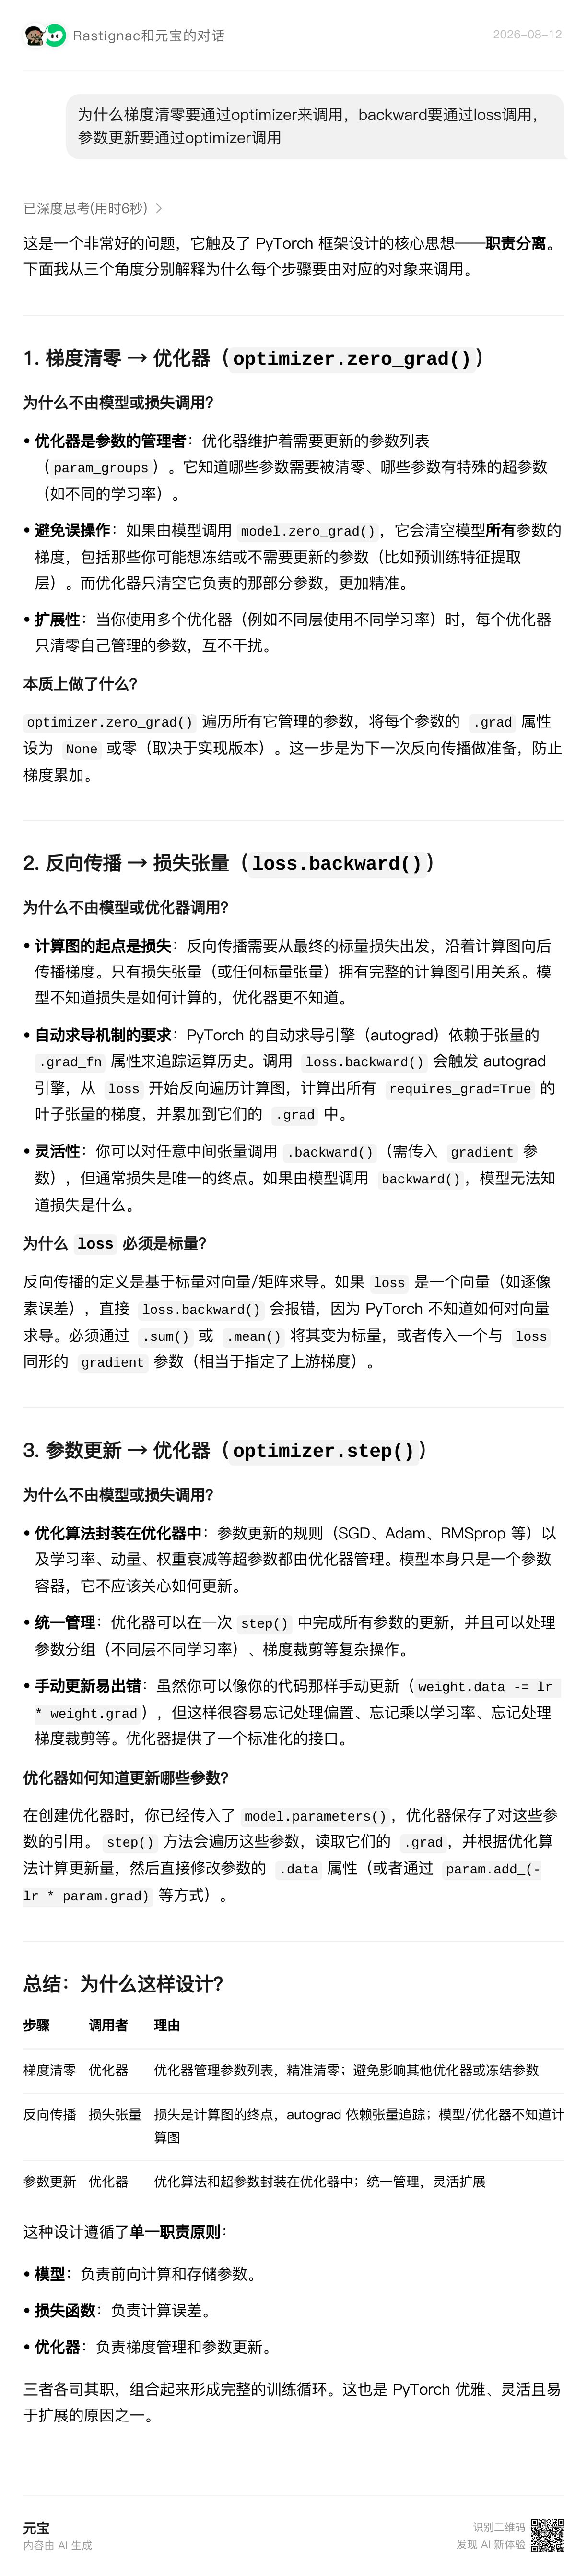
